# Notebook 04: Normalización territorial por distancia a comisarías

**Proyecto:** Delitos geolocalizados en CABA 2023  
**Entrada principal:** `delitos_2023_caba_enriquecido_comisarias.csv`  
**Objetivo:** revisar la hipótesis preliminar incorporando la superficie real de cada franja de distancia.

## Idea central

El Notebook 03 mostró una lectura preliminar en cantidades absolutas:

- 0-500 m: menos delitos que 501-900 m;
- 501-900 m: máximo absoluto;
- luego los delitos bajan.

Pero las franjas no tienen la misma superficie. Este notebook calcula cuántos km² ocupa cada franja y transforma la cantidad absoluta de delitos en una tasa territorial:

```text
delitos por km² = cantidad de delitos / superficie de la franja
```

Esto permite distinguir cantidad bruta de concentración territorial.

## 1. Dependencias

Este notebook usa `geopandas`, `shapely` y `matplotlib`.

Si falta alguna librería, instalarla una vez en el entorno virtual:

```powershell
python -m pip install geopandas shapely pyproj matplotlib pandas
```

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.ops import unary_union
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 2. Rutas del proyecto

In [2]:
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "datasets" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def find_file(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró ninguno de estos archivos:\n"
        + "\n".join(str(c) for c in candidates)
    )

ENRICHED_CRIME_FILE = find_file([
    PROCESSED_DATA_DIR / "delitos_2023_caba_enriquecido_comisarias.csv",
    PROJECT_ROOT / "delitos_2023_caba_enriquecido_comisarias.csv",
    Path("/mnt/data/delitos_2023_caba_enriquecido_comisarias.csv"),
])

STATIONS_FILE = find_file([
    RAW_DATA_DIR / "comisarias_policia(1).csv",
    RAW_DATA_DIR / "comisarias_policia.csv",
    PROJECT_ROOT / "comisarias_policia(1).csv",
    PROJECT_ROOT / "comisarias_policia.csv",
    Path("/mnt/data/comisarias_policia(1).csv"),
])

NEIGHBORHOODS_FILE = find_file([
    RAW_DATA_DIR / "barrios.csv",
    PROJECT_ROOT / "barrios.csv",
    Path("/mnt/data/barrios.csv"),
])

print("Archivo de delitos enriquecido:", ENRICHED_CRIME_FILE)
print("Archivo de sedes policiales:", STATIONS_FILE)
print("Archivo de barrios:", NEIGHBORHOODS_FILE)

Archivo de delitos enriquecido: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\processed\delitos_2023_caba_enriquecido_comisarias.csv
Archivo de sedes policiales: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\raw\comisarias_policia.csv
Archivo de barrios: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\raw\barrios.csv


## 3. Carga del dataset enriquecido

In [3]:
delitos = pd.read_csv(
    ENRICHED_CRIME_FILE,
    low_memory=False,
)

required_columns = {
    "franja_distancia_comisaria",
    "distancia_comisaria_metros",
}

missing_columns = sorted(required_columns - set(delitos.columns))

if missing_columns:
    raise ValueError(
        f"Faltan columnas requeridas en el dataset enriquecido: {missing_columns}"
    )

print("Filas cargadas:", len(delitos))
display(delitos[[
    "id_mapa",
    "tipo",
    "subtipo",
    "barrio",
    "comuna",
    "comisaria_jurisdiccional",
    "comisaria_mas_cercana",
    "distancia_comisaria_metros",
    "franja_distancia_comisaria",
]].head())

Filas cargadas: 152739


,id_mapa,tipo,subtipo,barrio,comuna,comisaria_jurisdiccional,comisaria_mas_cercana,distancia_comisaria_metros,franja_distancia_comisaria
0,1114988,Amenazas,Amenazas,BOCA,4,Comisaría Vecinal 4-C,Comisaría Vecinal 4-C — PINZON 456,1487,ALEJADA (MAS DE 1350 m)
1,1114989,Amenazas,Amenazas,BOCA,4,Comisaría Vecinal 4-C,Comisaría Vecinal 4-C — PINZON 456,1487,ALEJADA (MAS DE 1350 m)
2,1114990,Amenazas,Amenazas,BOCA,4,Comisaría Vecinal 4-C,Comisaría Vecinal 4-C — PINZON 456,1487,ALEJADA (MAS DE 1350 m)
3,1114991,Amenazas,Amenazas,BOCA,4,Comisaría Vecinal 4-C,Comisaría Vecinal 4-C — PINZON 456,661,CERCANA (501-900 m)
4,1114992,Amenazas,Amenazas,BOCA,4,Comisaría Vecinal 4-C,Comisaría Vecinal 4-C — PINZON 456,636,CERCANA (501-900 m)


## 4. Construcción territorial de las franjas

Se toma la geometría completa de CABA a partir de los polígonos barriales.

Luego se generan áreas de influencia alrededor de las sedes policiales físicas únicas:

- 0-500 m;
- 501-900 m;
- 901-1350 m;
- más de 1350 m.

La última franja es todo el resto de CABA que queda fuera del buffer de 1350 metros.

In [4]:
def prepare_distance_zones(neighborhoods_file, stations_file):
    barrios = pd.read_csv(neighborhoods_file)
    sedes = pd.read_csv(stations_file)

    barrios["geometry"] = barrios["geometry"].apply(wkt.loads)
    sedes["geometry"] = sedes["geometry"].apply(wkt.loads)

    barrios_gdf = gpd.GeoDataFrame(
        barrios,
        geometry="geometry",
        crs="EPSG:4326",
    )

    sedes_gdf = gpd.GeoDataFrame(
        sedes,
        geometry="geometry",
        crs="EPSG:4326",
    )

    metric_crs = barrios_gdf.estimate_utm_crs()

    barrios_m = barrios_gdf.to_crs(metric_crs)
    sedes_m = sedes_gdf.to_crs(metric_crs)

    # Se eliminan duplicados físicos: hay 75 registros administrativos,
    # pero 63 sedes físicas únicas.
    sedes_m["x_coord"] = sedes_m.geometry.x.round(3)
    sedes_m["y_coord"] = sedes_m.geometry.y.round(3)
    sedes_unicas_m = sedes_m.drop_duplicates(
        subset=["x_coord", "y_coord"],
    ).copy()

    caba_geom = unary_union(barrios_m.geometry)

    band_specs = [
        {
            "orden": 1,
            "franja_distancia_comisaria": "ENTORNO INMEDIATO (0-500 m)",
            "desde_m": 0,
            "hasta_m": 500,
        },
        {
            "orden": 2,
            "franja_distancia_comisaria": "CERCANA (501-900 m)",
            "desde_m": 501,
            "hasta_m": 900,
        },
        {
            "orden": 3,
            "franja_distancia_comisaria": "INTERMEDIA (901-1350 m)",
            "desde_m": 901,
            "hasta_m": 1350,
        },
        {
            "orden": 4,
            "franja_distancia_comisaria": "ALEJADA (MAS DE 1350 m)",
            "desde_m": 1351,
            "hasta_m": None,
        },
    ]

    cumulative_radii = [500, 900, 1350]
    previous = None
    zone_geometries = []

    for radius in cumulative_radii:
        buffer_union = unary_union(sedes_unicas_m.buffer(radius))
        clipped = caba_geom.intersection(buffer_union)

        if previous is None:
            ring = clipped
        else:
            ring = clipped.difference(previous)

        zone_geometries.append(ring)
        previous = clipped

    zone_geometries.append(caba_geom.difference(previous))

    zonas = gpd.GeoDataFrame(
        band_specs,
        geometry=zone_geometries,
        crs=metric_crs,
    )

    zonas["superficie_km2"] = zonas.geometry.area / 1_000_000

    return zonas, barrios_m, sedes_unicas_m, metric_crs

In [5]:
zonas_distancia, barrios_m, sedes_unicas_m, metric_crs = prepare_distance_zones(
    NEIGHBORHOODS_FILE,
    STATIONS_FILE,
)

print("CRS métrico usado:", metric_crs)
print("Cantidad de sedes físicas únicas:", len(sedes_unicas_m))
print("Superficie total reconstruida de CABA:", zonas_distancia["superficie_km2"].sum().round(2), "km²")

display(zonas_distancia[[
    "orden",
    "franja_distancia_comisaria",
    "desde_m",
    "hasta_m",
    "superficie_km2",
]])

CRS métrico usado: EPSG:32721
Cantidad de sedes físicas únicas: 63
Superficie total reconstruida de CABA: 203.91 km²


,orden,franja_distancia_comisaria,desde_m,hasta_m,superficie_km2
0,1,ENTORNO INMEDIATO (0-500 m),0,500.00,43.05
1,2,CERCANA (501-900 m),501,900.00,63.86
2,3,INTERMEDIA (901-1350 m),901,"1,350.00",53.11
3,4,ALEJADA (MAS DE 1350 m),1351,NaN,43.88


## 5. Delitos absolutos vs. delitos por km²

Ahora se cruzan las cantidades de delitos registradas en cada franja con la superficie territorial de esa franja.

In [6]:
orden_franjas = zonas_distancia.sort_values("orden")["franja_distancia_comisaria"].tolist()

conteo_delitos = (
    delitos
    .groupby("franja_distancia_comisaria")
    .size()
    .reindex(orden_franjas)
    .rename("cantidad_delitos")
    .reset_index()
)

reporte_territorial = (
    zonas_distancia[[
        "orden",
        "franja_distancia_comisaria",
        "desde_m",
        "hasta_m",
        "superficie_km2",
    ]]
    .merge(
        conteo_delitos,
        on="franja_distancia_comisaria",
        how="left",
    )
    .sort_values("orden")
)

reporte_territorial["cantidad_delitos"] = reporte_territorial["cantidad_delitos"].fillna(0).astype(int)
reporte_territorial["porcentaje_delitos"] = (
    reporte_territorial["cantidad_delitos"]
    / reporte_territorial["cantidad_delitos"].sum()
    * 100
)
reporte_territorial["porcentaje_superficie"] = (
    reporte_territorial["superficie_km2"]
    / reporte_territorial["superficie_km2"].sum()
    * 100
)
reporte_territorial["delitos_por_km2"] = (
    reporte_territorial["cantidad_delitos"]
    / reporte_territorial["superficie_km2"]
)
reporte_territorial["indice_vs_0_500"] = (
    reporte_territorial["delitos_por_km2"]
    / reporte_territorial.loc[
        reporte_territorial["orden"] == 1,
        "delitos_por_km2",
    ].iloc[0]
)

display(reporte_territorial)

,orden,franja_distancia_comisaria,desde_m,hasta_m,superficie_km2,cantidad_delitos,porcentaje_delitos,porcentaje_superficie,delitos_por_km2,indice_vs_0_500
0,1,ENTORNO INMEDIATO (0-500 m),0,500.00,43.05,47871,31.34,21.11,"1,112.05",1.00
1,2,CERCANA (501-900 m),501,900.00,63.86,55074,36.06,31.32,862.36,0.78
2,3,INTERMEDIA (901-1350 m),901,"1,350.00",53.11,31953,20.92,26.05,601.59,0.54
3,4,ALEJADA (MAS DE 1350 m),1351,NaN,43.88,17841,11.68,21.52,406.59,0.37


## 6. Visualización: cantidad absoluta y concentración territorial

La cantidad absoluta sube de 0-500 m a 501-900 m.  
Pero al dividir por superficie, la concentración territorial baja de manera progresiva.

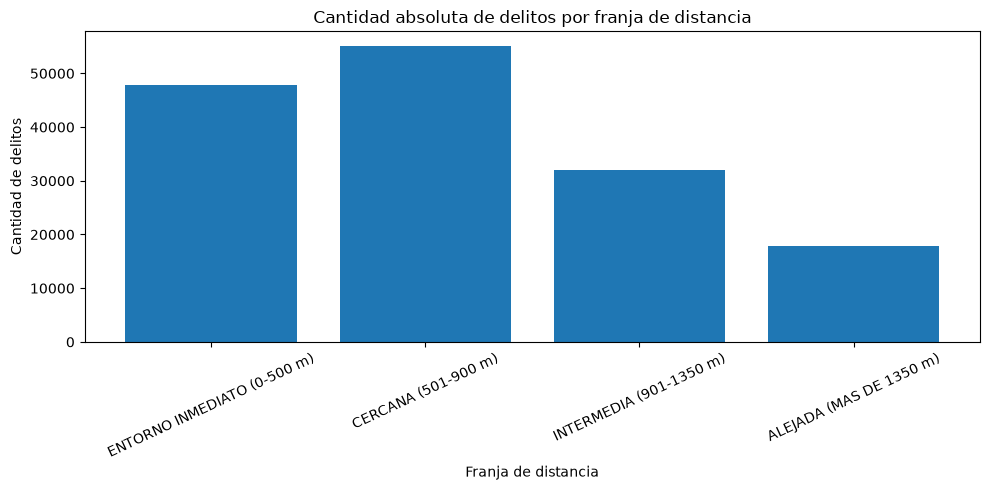

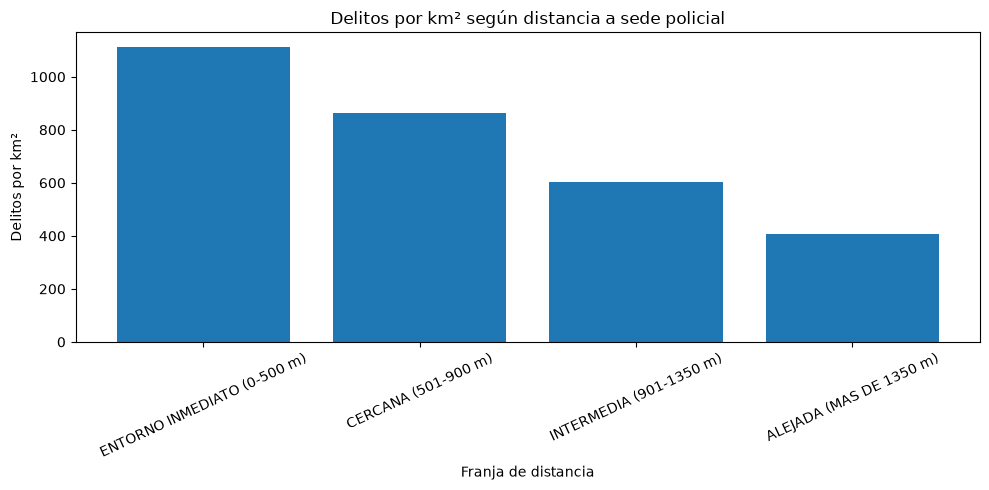

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    reporte_territorial["franja_distancia_comisaria"],
    reporte_territorial["cantidad_delitos"],
)
ax.set_title("Cantidad absoluta de delitos por franja de distancia")
ax.set_xlabel("Franja de distancia")
ax.set_ylabel("Cantidad de delitos")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "cantidad_absoluta_delitos_por_franja_distancia.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    reporte_territorial["franja_distancia_comisaria"],
    reporte_territorial["delitos_por_km2"],
)
ax.set_title("Delitos por km² según distancia a sede policial")
ax.set_xlabel("Franja de distancia")
ax.set_ylabel("Delitos por km²")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "delitos_por_km2_por_franja_distancia.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 7. Guardado de reportes

Se guardan:

- una tabla con superficie, delitos y delitos por km²;
- un GeoJSON con las zonas de distancia, útil para mapas o paneles posteriores.

In [8]:
territorial_report_file = TABLES_DIR / "reporte_normalizacion_territorial.csv"
zones_file = PROCESSED_DATA_DIR / "zonas_distancia_comisarias.geojson"

reporte_territorial.to_csv(
    territorial_report_file,
    index=False,
    encoding="utf-8-sig",
)

zonas_distancia.to_crs("EPSG:4326").to_file(
    zones_file,
    driver="GeoJSON",
)

print("Reporte territorial guardado en:", territorial_report_file)
print("Zonas de distancia guardadas en:", zones_file)

Reporte territorial guardado en: C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\reporte_normalizacion_territorial.csv
Zonas de distancia guardadas en: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\processed\zonas_distancia_comisarias.geojson


## 8. Conclusión del notebook

La lectura preliminar en valores absolutos sugería que la franja 0-500 m tenía menos delitos que la franja 501-900 m.

Sin embargo, al normalizar por superficie, se observa que:

- la franja 0-500 m tiene la mayor concentración de delitos por km²;
- la tasa territorial baja progresivamente al aumentar la distancia;
- el pico absoluto de 501-900 m se explica por una mayor exposición territorial.

**Conclusión:** los datos no respaldan un efecto disuasorio visible asociado a la cercanía física con una sede policial. La menor cantidad absoluta en 0-500 m se explica por su menor superficie total.